In [1]:
# Fig3: Dissecting the structural basis of burst and sustained dynamics through domain swapping
# Analysis to identify the three behavioral groups from the paper:
# 1. Slow-sustained: prolonged motion >12 h, velocity 10-50 nm/s
# 2. Fast-burst: brief motion < 2 h, velocity 50-1000 nm/s  
# 3. Multiphase: concentration-dependent transitions

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load and prepare data for behavioral classification
df = pd.read_csv('../../../Thomson Lab Dropbox/David Larios/activedrops/main/all/motor_dataset.csv')

# Keep essential columns for behavioral analysis (removed Translation Rate aa_s as it was faulty)
columns_to_keep = ['time (s)',  'Protein Concentration_nM', 'vorticity [1/s]_mean', 'velocity magnitude [m/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'protein', 'DNA nM']
df = df[columns_to_keep]

# Remove rows with missing protein names
df = df.dropna(subset=['protein'])

# Remove proteins that have only NaNs in velocity magnitude column
print("Before filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")

# Check which proteins have only NaN velocity measurements
velocity_nan_by_protein = df.groupby('protein')['velocity magnitude [m/s]_mean'].apply(lambda x: x.isna().all())
proteins_with_nan_velocity = velocity_nan_by_protein[velocity_nan_by_protein].index.tolist()

print(f"\nProteins with only NaN velocity measurements: {proteins_with_nan_velocity}")

# Remove these proteins
df = df[~df['protein'].isin(proteins_with_nan_velocity)]

print(f"\nAfter filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")
print(f"Remaining proteins: {df['protein'].unique()}")

# Check data quality
print(f"\nData quality check:")
print(f"Rows with valid velocity data: {df['velocity magnitude [m/s]_mean'].notna().sum()}")
print(f"Rows with valid time data: {df['time (s)'].notna().sum()}")
print(f"Rows with valid protein data: {df['protein'].notna().sum()}")

df

Before filtering:
Total rows: 177676
Unique proteins: 16

Proteins with only NaN velocity measurements: ['B', 'BleSto', 'E', 'F']

After filtering:
Total rows: 173452
Unique proteins: 12
Remaining proteins: ['A' 'H' 'C' 'G' 'D' 'ThTr' 'AcSu2' 'DiPu' 'HeAl' 'NaGr' 'AdPa' 'Kif5']

Data quality check:
Rows with valid velocity data: 119708
Rows with valid time data: 173452
Rows with valid protein data: 173452


,time (s),Protein Concentration_nM,vorticity [1/s]_mean,velocity magnitude [m/s]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,distance [m]_mean,power [W]_mean,work [J]_mean,protein,DNA nM
0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25
1,600.0,1.909813,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25
2,1200.0,3.075428,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25
3,1800.0,4.749361,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25
4,2400.0,6.528183,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1.25
...,...,...,...,...,...,...,...,...,...,...,...,...
238316,131220.0,122.844224,7.554028e-08,6.008068e-10,1.705629e-07,-1.453127e-07,0.000112,0.000722,5.768031e-23,5.727192e-18,Kif5,160.00
238317,131265.0,122.777871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00
238318,131310.0,122.759158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00
238319,131355.0,122.815775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5,160.00


In [3]:
# Data quality analysis (self-contained)
print("\n" + "="*80)
print("DATA QUALITY ANALYSIS")
print("="*80)

# Define proteins and dna_concentrations locally for robustness
proteins = sorted([p for p in df['protein'].unique() if pd.notna(p)])
dna_concentrations = sorted([d for d in df['DNA nM'].unique() if pd.notna(d)])

# Analyze missing data patterns
print("Missing data patterns by protein:")
for protein in proteins:
    protein_data = df[df['protein'] == protein]
    total_rows = len(protein_data)
    if total_rows == 0:
        continue
    valid_velocity = protein_data['velocity magnitude [m/s]_mean'].notna().sum()
    valid_time = protein_data['time (s)'].notna().sum()
    valid_both = protein_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean']).shape[0]
    
    print(f"  {protein:8s}: {total_rows:6d} total rows, {valid_velocity:6d} valid velocity ({(valid_velocity/total_rows*100):5.1f}%), {valid_both:6d} valid both ({(valid_both/total_rows*100):5.1f}%)")

print(f"\nMissing data patterns by DNA concentration:")
for dna_conc in dna_concentrations:
    conc_data = df[df['DNA nM'] == dna_conc]
    total_rows = len(conc_data)
    if total_rows == 0:
        continue
    valid_velocity = conc_data['velocity magnitude [m/s]_mean'].notna().sum()
    valid_both = conc_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean']).shape[0]
    
    print(f"  {dna_conc:8.1f} nM: {total_rows:6d} total rows, {valid_velocity:6d} valid velocity ({(valid_velocity/total_rows*100):5.1f}%), {valid_both:6d} valid both ({(valid_both/total_rows*100):5.1f}%)")

# Check for complete protein-DNA combinations
print(f"\nComplete protein-DNA combinations (with valid velocity data):")
complete_combinations = 0
for protein in proteins:
    for dna_conc in dna_concentrations:
        combo_data = df[(df['protein'] == protein) & (df['DNA nM'] == dna_conc)]
        if not combo_data.empty:
            valid_data = combo_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean'])
            if not valid_data.empty:
                complete_combinations += 1
                print(f"  {protein} - {dna_conc} nM: {len(valid_data)} valid points")

print(f"\nTotal complete combinations: {complete_combinations}")
print(f"Total possible combinations: {len(proteins) * len(dna_concentrations)}")
print(f"Completion rate: {complete_combinations / (len(proteins) * len(dna_concentrations)) * 100:.1f}%")



DATA QUALITY ANALYSIS
Missing data patterns by protein:
  A       :   4130 total rows,   2960 valid velocity ( 71.7%),   2960 valid both ( 71.7%)
  AcSu2   :   7112 total rows,   7030 valid velocity ( 98.8%),   7030 valid both ( 98.8%)
  AdPa    :  29816 total rows,   1752 valid velocity (  5.9%),   1752 valid both (  5.9%)
  C       :   9466 total rows,   9466 valid velocity (100.0%),   9466 valid both (100.0%)
  D       :   5277 total rows,   5277 valid velocity (100.0%),   5277 valid both (100.0%)
  DiPu    :   1320 total rows,    990 valid velocity ( 75.0%),    990 valid both ( 75.0%)
  G       :  11872 total rows,  11872 valid velocity (100.0%),  11872 valid both (100.0%)
  H       :   4230 total rows,   4230 valid velocity (100.0%),   4230 valid both (100.0%)
  HeAl    :   7048 total rows,   7048 valid velocity (100.0%),   7048 valid both (100.0%)
  Kif5    :   2921 total rows,    973 valid velocity ( 33.3%),    973 valid both ( 33.3%)
  NaGr    :  30840 total rows,   8832 valid

Dataset shape: (173452, 12)

Column names:
['time (s)', 'Protein Concentration_nM', 'vorticity [1/s]_mean', 'velocity magnitude [m/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'protein', 'DNA nM']

Data types:
time (s)                         float64
Protein Concentration_nM         float64
vorticity [1/s]_mean             float64
velocity magnitude [m/s]_mean    float64
shear [1/s]_mean                 float64
strain [1/s]_mean                float64
correlation length [m]_mean      float64
distance [m]_mean                float64
power [W]_mean                   float64
work [J]_mean                    float64
protein                           object
DNA nM                           float64
dtype: object

Missing values:
time (s)                             0
Protein Concentration_nM         98838
vorticity [1/s]_mean             53744
velocity magnitude [m/s]_mean    53744
shear [1/s]_mean  

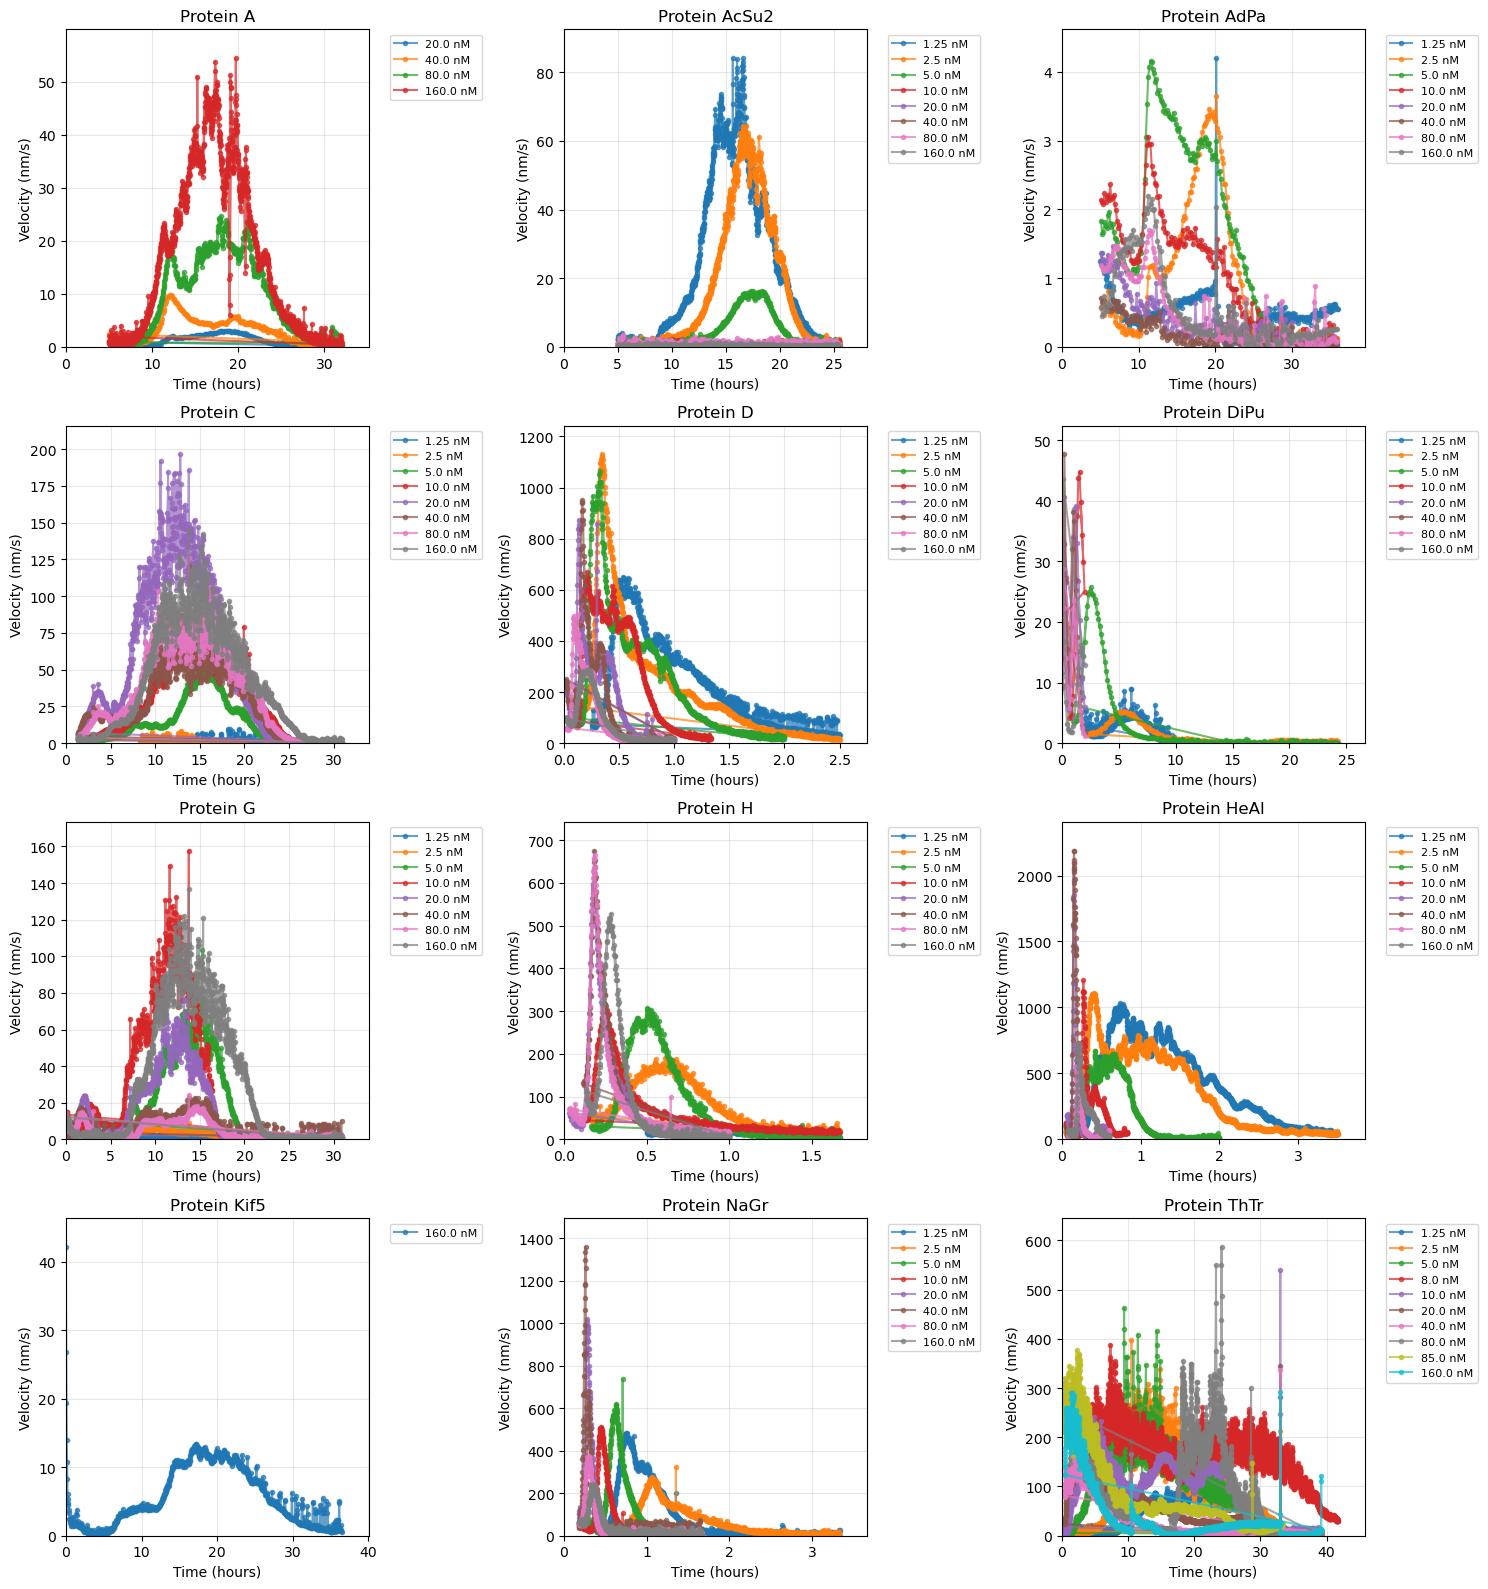


Plotting complete for 12 proteins


In [4]:
# First, let's examine the data structure and prepare for analysis
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

# Create velocity vs time plots for each protein across different DNA concentrations
print("\n" + "="*80)
print("VELOCITY vs TIME PLOTS FOR EACH PROTEIN")
print("="*80)

# Get unique proteins and DNA concentrations (remove NaN values)
proteins = sorted([p for p in df['protein'].unique() if pd.notna(p)])
dna_concentrations = sorted([d for d in df['DNA nM'].unique() if pd.notna(d)])

print(f"Proteins: {proteins}")
print(f"DNA concentrations: {dna_concentrations}")

# Create subplots for each protein
n_proteins = len(proteins)
n_cols = 3
n_rows = (n_proteins + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_proteins == 1:
    axes = [axes]
axes = axes.flatten()

for i, protein in enumerate(proteins):
    ax = axes[i]
    
    # Get data for this protein
    protein_data = df[df['protein'] == protein]
    print(f"\nProcessing protein {protein}: {len(protein_data)} rows")
    
    # Plot each DNA concentration as a separate line
    plotted_any = False
    for dna_conc in dna_concentrations:
        conc_data = protein_data[protein_data['DNA nM'] == dna_conc]
        if not conc_data.empty:
            # Convert time to hours and velocity to nm/s
            time_hours = conc_data['time (s)'] / 3600
            velocity_nm_s = conc_data['velocity magnitude [m/s]_mean'] * 1e9
            
            # Only plot if we have valid data
            valid_mask = ~velocity_nm_s.isna() & ~time_hours.isna()
            if valid_mask.any():
                ax.plot(time_hours[valid_mask], velocity_nm_s[valid_mask], 
                       marker='o', markersize=3, alpha=0.7, 
                       label=f'{dna_conc} nM', linewidth=1.5)
                plotted_any = True
                print(f"  DNA {dna_conc} nM: {valid_mask.sum()} valid points")
    
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Velocity (nm/s)')
    ax.set_title(f'Protein {protein}')
    ax.grid(True, alpha=0.3)
    
    if plotted_any:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        
        # Set reasonable axis limits
        if not protein_data.empty:
            valid_data = protein_data.dropna(subset=['time (s)', 'velocity magnitude [m/s]_mean'])
            if not valid_data.empty:
                max_time = valid_data['time (s)'].max() / 3600
                max_vel = valid_data['velocity magnitude [m/s]_mean'].max() * 1e9
                if not np.isnan(max_time) and not np.isnan(max_vel):
                    ax.set_xlim(0, max_time * 1.1)
                    ax.set_ylim(0, max_vel * 1.1)
    else:
        ax.text(0.5, 0.5, 'No valid data', transform=ax.transAxes, 
                ha='center', va='center', fontsize=12, alpha=0.5)

# Hide unused subplots
for i in range(n_proteins, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nPlotting complete for {n_proteins} proteins")


In [5]:
# Prepare data for clustering analysis
# We want to classify PROTEINS, not individual concentration conditions
# So we'll aggregate across all concentrations for each protein

print("Approach: Classify proteins based on their behavior across all concentrations")
print("=" * 70)

# Group by protein only to get summary statistics across all concentrations
df_protein_summary = df.groupby('protein').agg({
    'time (s)': ['max', 'mean', 'std'],  # Duration statistics
    'velocity magnitude [m/s]_mean': ['mean', 'max', 'std', 'min'],
    'power [W]_mean': ['mean', 'max', 'std'],
    'vorticity [1/s]_mean': ['mean', 'std'],
    'shear [1/s]_mean': ['mean', 'std'],
    'strain [1/s]_mean': ['mean', 'std'],
    'correlation length [m]_mean': ['mean', 'std'],
    'distance [m]_mean': ['mean', 'std'],
    'work [J]_mean': ['mean', 'max', 'std'],
    'Protein Concentration_nM': ['mean', 'max', 'std'],
    'DNA nM': ['nunique']  # Number of different DNA concentrations tested
}).reset_index()

# Flatten column names
df_protein_summary.columns = ['_'.join(col).strip() for col in df_protein_summary.columns.values]
df_protein_summary.columns = df_protein_summary.columns.str.replace('_<lambda_0>', '')

# Fix the protein column name
df_protein_summary = df_protein_summary.rename(columns={'protein_': 'protein'})

print("Protein-level summary dataset shape:", df_protein_summary.shape)
print("\nProteins analyzed:")
print(df_protein_summary['protein'].tolist())
print("\nSummary columns:")
print(df_protein_summary.columns.tolist())
df_protein_summary.head()


Approach: Classify proteins based on their behavior across all concentrations
Protein-level summary dataset shape: (12, 28)

Proteins analyzed:
['A', 'AcSu2', 'AdPa', 'C', 'D', 'DiPu', 'G', 'H', 'HeAl', 'Kif5', 'NaGr', 'ThTr']

Summary columns:
['protein', 'time (s)_max', 'time (s)_mean', 'time (s)_std', 'velocity magnitude [m/s]_mean_mean', 'velocity magnitude [m/s]_mean_max', 'velocity magnitude [m/s]_mean_std', 'velocity magnitude [m/s]_mean_min', 'power [W]_mean_mean', 'power [W]_mean_max', 'power [W]_mean_std', 'vorticity [1/s]_mean_mean', 'vorticity [1/s]_mean_std', 'shear [1/s]_mean_mean', 'shear [1/s]_mean_std', 'strain [1/s]_mean_mean', 'strain [1/s]_mean_std', 'correlation length [m]_mean_mean', 'correlation length [m]_mean_std', 'distance [m]_mean_mean', 'distance [m]_mean_std', 'work [J]_mean_mean', 'work [J]_mean_max', 'work [J]_mean_std', 'Protein Concentration_nM_mean', 'Protein Concentration_nM_max', 'Protein Concentration_nM_std', 'DNA nM_nunique']


,protein,time (s)_max,time (s)_mean,time (s)_std,velocity magnitude [m/s]_mean_mean,velocity magnitude [m/s]_mean_max,velocity magnitude [m/s]_mean_std,velocity magnitude [m/s]_mean_min,power [W]_mean_mean,power [W]_mean_max,...,correlation length [m]_mean_std,distance [m]_mean_mean,distance [m]_mean_std,work [J]_mean_mean,work [J]_mean_max,work [J]_mean_std,Protein Concentration_nM_mean,Protein Concentration_nM_max,Protein Concentration_nM_std,DNA nM_nunique
0,A,156600.0,69568.852300,33731.459097,1.166207e-08,5.441118e-08,1.291416e-08,0.0,2.060966e-20,2.505042e-19,...,0.000092,0.000788,0.000580,2.141627e-17,5.711638e-17,2.153769e-17,537.581150,1519.259087,375.584530,8
1,AcSu2,92000.0,55000.000000,21387.491498,8.839441e-09,8.407517e-08,1.665935e-08,0.0,2.742836e-20,4.904973e-19,...,0.000039,0.000506,0.000505,2.057913e-17,1.136368e-16,3.542430e-17,3511.385186,7524.445323,2042.715455,8
2,AdPa,129780.0,73890.000000,32277.306917,6.907255e-10,4.199285e-09,8.084400e-10,0.0,6.410981e-23,2.269441e-21,...,0.000123,0.000147,0.000050,8.033457e-20,1.959047e-19,4.684553e-20,387.583121,785.797966,196.692192,8
3,C,111225.0,57872.966406,29447.536424,2.921491e-08,1.964161e-07,3.363148e-08,0.0,1.378054e-18,5.243438e-17,...,0.000092,0.001806,0.001665,1.095090e-15,6.129248e-15,1.725357e-15,831.802530,1938.570576,568.745514,8
4,D,9000.0,3408.344135,2282.540593,1.944080e-07,1.129651e-06,2.058472e-07,0.0,3.538945e-18,5.519847e-17,...,0.000088,0.000960,0.000646,2.057320e-15,5.621630e-15,1.695989e-15,28.920571,84.524927,19.174081,8


In [6]:
# Compute translation rate (d[Protein]_nM/dt) per (protein, DNA) and add to df
print("\n" + "="*80)
print("COMPUTE TRANSLATION RATE AND PEAK TIMING")
print("="*80)

from scipy.stats import linregress

# Initialize new columns
df['translation rate [nM/s]'] = np.nan

# Per-condition summaries to capture relationships vs DNA
per_condition_records = []

for (prot, dna), g in df.dropna(subset=['protein']).groupby(['protein', 'DNA nM'], dropna=False):
    g_sorted = g.sort_values('time (s)').copy()
    t = g_sorted['time (s)'].values
    pc = g_sorted['Protein Concentration_nM'].values
    v = g_sorted['velocity magnitude [m/s]_mean'].values
    pwr = g_sorted['power [W]_mean'].values

    # Compute translation rate via gradient (handle missing)
    valid = ~np.isnan(t) & ~np.isnan(pc)
    tr = np.full_like(pc, np.nan, dtype=float)
    if np.sum(valid) >= 2 and np.all(np.diff(t[valid]) > 0):
        tr_valid = np.gradient(pc[valid], t[valid])
        tr[valid] = tr_valid

    # Assign back into df
    df.loc[g_sorted.index, 'translation rate [nM/s]'] = tr

    # Condition summaries
    max_vel = np.nanmax(v) if v.size else np.nan
    max_pwr = np.nanmax(pwr) if pwr.size else np.nan
    # Approximate energy as integral of power over time (J)
    energy_j = np.nan
    if np.sum(~np.isnan(pwr) & ~np.isnan(t)) >= 2:
        tv = t[~np.isnan(pwr) & ~np.isnan(t)]
        pv = pwr[~np.isnan(pwr) & ~np.isnan(t)]
        if np.all(np.diff(tv) > 0):
            energy_j = float(np.trapz(pv, tv))

    # Translation rate peaks
    max_tr = np.nanmax(tr) if np.any(~np.isnan(tr)) else np.nan
    time_to_peak_tr_h = np.nan
    if np.any(~np.isnan(tr)):
        idx = np.nanargmax(tr)
        if not np.isnan(t[idx]):
            time_to_peak_tr_h = t[idx] / 3600.0

    per_condition_records.append({
        'protein': prot,
        'DNA nM': dna,
        'max_velocity_m_per_s': max_vel,
        'max_power_W': max_pwr,
        'energy_J': energy_j,
        'max_translation_rate_nM_per_s': max_tr,
        'time_to_peak_translation_rate_hours': time_to_peak_tr_h,
    })

per_condition_df = pd.DataFrame(per_condition_records)
print("Per-condition summary head:")
print(per_condition_df.head())

# Aggregate translation rate features per protein
per_protein_tr = per_condition_df.groupby('protein').agg({
    'max_translation_rate_nM_per_s': ['mean', 'max'],
    'time_to_peak_translation_rate_hours': ['mean', 'std']
}).reset_index()
per_protein_tr.columns = ['_'.join(col).strip('_') for col in per_protein_tr.columns.values]
per_protein_tr = per_protein_tr.rename(columns={'protein_': 'protein'})

# Merge into protein summary
df_protein_summary = df_protein_summary.merge(per_protein_tr, on='protein', how='left')

# Compute DNA concentration dependence per protein via regression (slope and r)
reg_records = []
for prot, g in per_condition_df.groupby('protein'):
    # Filter rows with valid DNA and metric
    def regress(y):
        sub = g.dropna(subset=['DNA nM', y])
        if len(sub) >= 2 and sub['DNA nM'].nunique() >= 2:
            res = linregress(sub['DNA nM'].values.astype(float), sub[y].values.astype(float))
            return {'slope': res.slope, 'r': res.rvalue}
        return {'slope': np.nan, 'r': np.nan}

    mv = regress('max_velocity_m_per_s')
    mp = regress('max_power_W')
    en = regress('energy_J')

    reg_records.append({
        'protein': prot,
        'slope_max_velocity_vs_DNA': mv['slope'],
        'r_max_velocity_vs_DNA': mv['r'],
        'slope_max_power_vs_DNA': mp['slope'],
        'r_max_power_vs_DNA': mp['r'],
        'slope_energy_vs_DNA': en['slope'],
        'r_energy_vs_DNA': en['r'],
    })

reg_df = pd.DataFrame(reg_records)

# Merge regression features
df_protein_summary = df_protein_summary.merge(reg_df, on='protein', how='left')

print("\nAdded DNA-concentration dependence features (slopes and r) to df_protein_summary.")
print(df_protein_summary.columns.tolist())



COMPUTE TRANSLATION RATE AND PEAK TIMING
Per-condition summary head:
  protein  DNA nM  max_velocity_m_per_s   max_power_W      energy_J  \
0       A    1.25                   NaN           NaN           NaN   
1       A    2.50                   NaN           NaN           NaN   
2       A    5.00                   NaN           NaN           NaN   
3       A   10.00                   NaN           NaN           NaN   
4       A   20.00          3.098720e-09  1.418586e-22  3.317521e-18   

   max_translation_rate_nM_per_s  time_to_peak_translation_rate_hours  
0                       0.011435                            29.833333  
1                       0.012155                            27.333333  
2                       0.013433                            27.500000  
3                       0.013867                            27.333333  
4                       0.018273                            19.666667  

Added DNA-concentration dependence features (slopes and r) to df_prote

In [7]:
# Compute per-protein duration at >=20% of max velocity across all concentrations
print("\n" + "="*80)
print("COMPUTE DURATION >= 20% OF MAX VELOCITY (per protein)")
print("="*80)

# Helper to compute duration above threshold within a single (protein, DNA) group
def _duration_above_threshold_seconds(group: pd.DataFrame) -> float:
    g = group.sort_values('time (s)')
    v = g['velocity magnitude [m/s]_mean']
    t = g['time (s)']
    if v.dropna().empty:
        return 0.0
    vmax = v.max()
    if pd.isna(vmax) or vmax <= 0:
        return 0.0
    thr = 0.2 * vmax
    mask = (v >= thr)
    # valid consecutive points above threshold
    valid = mask & t.notna() & v.notna()
    if valid.sum() < 2:
        return 0.0
    t_valid = t[valid].values
    # sum positive deltas between consecutive valid times
    dt = np.diff(t_valid)
    dt = dt[dt > 0]
    return float(np.sum(dt)) if len(dt) else 0.0

# Compute per (protein, DNA) durations, then sum across DNA to get per protein total
durations = (
    df.dropna(subset=['protein'])
      .groupby(['protein', 'DNA nM'], dropna=False)
      .apply(_duration_above_threshold_seconds)
      .reset_index(name='duration_high_velocity_s_by_condition')
)

protein_duration = (
    durations.groupby('protein', dropna=False)['duration_high_velocity_s_by_condition']
             .sum()
             .reset_index()
)
protein_duration['duration_high_velocity_hours'] = protein_duration['duration_high_velocity_s_by_condition'] / 3600.0

print("Per-protein duration (hours) at >=20% vmax:")
print(protein_duration[['protein', 'duration_high_velocity_hours']])

# Merge into df_protein_summary
df_protein_summary = df_protein_summary.merge(
    protein_duration[['protein', 'duration_high_velocity_hours']],
    on='protein', how='left'
)

# Fill NaNs with 0 if any
df_protein_summary['duration_high_velocity_hours'] = df_protein_summary['duration_high_velocity_hours'].fillna(0.0)

print("\nUpdated df_protein_summary columns (added duration_high_velocity_hours):")
print(df_protein_summary.columns.tolist())



COMPUTE DURATION >= 20% OF MAX VELOCITY (per protein)
Per-protein duration (hours) at >=20% vmax:
   protein  duration_high_velocity_hours
0        A                     76.566667
1    AcSu2                    128.388889
2     AdPa                    176.950000
3        C                    112.187500
4        D                      5.304444
5     DiPu                     27.016667
6        G                    118.895833
7        H                      4.495556
8     HeAl                      5.510000
9     Kif5                     26.025000
10    NaGr                      3.366667
11    ThTr                    309.729167

Updated df_protein_summary columns (added duration_high_velocity_hours):
['protein', 'time (s)_max', 'time (s)_mean', 'time (s)_std', 'velocity magnitude [m/s]_mean_mean', 'velocity magnitude [m/s]_mean_max', 'velocity magnitude [m/s]_mean_std', 'velocity magnitude [m/s]_mean_min', 'power [W]_mean_mean', 'power [W]_mean_max', 'power [W]_mean_std', 'vorticity [1/s]_

In [8]:
# Select features for clustering analysis
# Focus on the key metrics that define the behavioral groups

# First, let's see what columns are actually available
print("Available columns in df_protein_summary:")
print(df_protein_summary.columns.tolist())
print()

# Select features that capture protein behavior across all concentrations
# Exclude: 'time (s)_max', 'time (s)_mean', 'velocity magnitude [m/s]_mean_min',
#          'DNA nM_nunique', 'distance [m]_mean_mean'
# Include new feature: 'duration_high_velocity_hours'
features = [
    'velocity magnitude [m/s]_mean_mean',  # Average velocity across concentrations
    'velocity magnitude [m/s]_mean_max',   # Peak velocity across concentrations
    'velocity magnitude [m/s]_mean_std',   # Velocity variability across concentrations
    'power [W]_mean_mean',                 # Average power across concentrations
    'power [W]_mean_max',                  # Peak power across concentrations
    'work [J]_mean_mean',                  # Average work across concentrations
    'work [J]_mean_max',                   # Peak work across concentrations
    'vorticity [1/s]_mean_mean',           # Average vorticity
    'shear [1/s]_mean_mean',               # Average shear
    'strain [1/s]_mean_mean',              # Average strain
    'correlation length [m]_mean_mean',    # Average correlation length
    'duration_high_velocity_hours'         # New duration feature
]

# Filter to only include features that exist in the dataframe
available_features = [f for f in features if f in df_protein_summary.columns]
print(f"Features to use: {available_features}")

# Create feature matrix
X = df_protein_summary[available_features].copy()

# Handle missing values
X = X.fillna(X.median())

print(f"\nFeature matrix shape: {X.shape}")
print(f"Number of proteins: {len(df_protein_summary)}")
print("\nFeatures used:")
for i, feature in enumerate(available_features):
    print(f"{i+1:2d}. {feature}")

print("\nFeature statistics:")
X.describe()


Available columns in df_protein_summary:
['protein', 'time (s)_max', 'time (s)_mean', 'time (s)_std', 'velocity magnitude [m/s]_mean_mean', 'velocity magnitude [m/s]_mean_max', 'velocity magnitude [m/s]_mean_std', 'velocity magnitude [m/s]_mean_min', 'power [W]_mean_mean', 'power [W]_mean_max', 'power [W]_mean_std', 'vorticity [1/s]_mean_mean', 'vorticity [1/s]_mean_std', 'shear [1/s]_mean_mean', 'shear [1/s]_mean_std', 'strain [1/s]_mean_mean', 'strain [1/s]_mean_std', 'correlation length [m]_mean_mean', 'correlation length [m]_mean_std', 'distance [m]_mean_mean', 'distance [m]_mean_std', 'work [J]_mean_mean', 'work [J]_mean_max', 'work [J]_mean_std', 'Protein Concentration_nM_mean', 'Protein Concentration_nM_max', 'Protein Concentration_nM_std', 'DNA nM_nunique', 'max_translation_rate_nM_per_s_mean', 'max_translation_rate_nM_per_s_max', 'time_to_peak_translation_rate_hours_mean', 'time_to_peak_translation_rate_hours_std', 'slope_max_velocity_vs_DNA', 'r_max_velocity_vs_DNA', 'slope_m

,velocity magnitude [m/s]_mean_mean,velocity magnitude [m/s]_mean_max,velocity magnitude [m/s]_mean_std,power [W]_mean_mean,power [W]_mean_max,work [J]_mean_mean,work [J]_mean_max,vorticity [1/s]_mean_mean,shear [1/s]_mean_mean,strain [1/s]_mean_mean,correlation length [m]_mean_mean,duration_high_velocity_hours
count,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,1.200000e+01,12.000000,12.000000
mean,6.542424e-08,5.436664e-07,7.583373e-08,1.890564e-18,5.928895e-17,2.677228e-15,1.044019e-14,1.935789e-06,-3.311597e-07,8.183612e-07,0.000189,82.869699
std,9.157742e-08,6.900997e-07,9.543027e-08,3.374014e-18,9.264840e-17,5.153011e-15,2.302915e-14,3.325244e-06,2.302671e-06,1.635241e-06,0.000042,93.127710
min,6.907255e-10,4.199285e-09,8.084400e-10,6.410981e-23,2.269441e-21,8.033457e-20,1.959047e-19,-8.789547e-07,-4.204411e-06,-4.341958e-07,0.000122,3.366667
25%,8.014382e-09,5.271688e-08,1.130935e-08,1.692878e-20,2.143128e-19,1.609094e-17,4.426909e-17,-2.413286e-08,-1.344796e-06,2.080911e-08,0.000162,5.458611
50%,2.089817e-08,1.770276e-07,2.810483e-08,6.443789e-19,1.785141e-17,3.799322e-16,1.756513e-15,2.430045e-07,6.867549e-08,2.208436e-07,0.000185,51.791667
75%,7.458678e-08,7.887160e-07,1.077162e-07,1.917976e-18,7.072146e-17,1.335647e-15,5.748535e-15,3.322569e-06,1.658222e-07,9.682948e-07,0.000215,121.269097
max,2.967703e-07,2.187885e-06,3.050931e-07,1.179192e-17,3.117907e-16,1.400139e-14,7.923105e-14,1.064795e-05,5.304169e-06,5.590322e-06,0.000277,309.729167


In [9]:
# Standardize the features for PCA and clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardized feature matrix shape:", X_scaled.shape)
print("Mean of standardized features:", X_scaled.mean(axis=0))
print("Std of standardized features:", X_scaled.std(axis=0))


Standardized feature matrix shape: (12, 12)
Mean of standardized features: [ 4.85722573e-17 -2.77555756e-17  7.40148683e-17  2.77555756e-17
  3.70074342e-17  7.40148683e-17  0.00000000e+00  1.85037171e-17
  6.47630098e-17 -3.70074342e-17 -6.10622664e-16  1.11022302e-16]
Std of standardized features: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [10]:
# Perform PCA analysis
from sklearn.decomposition import PCA

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratios
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("PCA Results:")
print("=" * 50)
print(f"Total variance explained by all components: {cumulative_variance[-1]:.4f}")
print(f"Number of components: {len(explained_variance_ratio)}")
print()

print("Explained variance by component:")
for i, (var_ratio, cum_var) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"PC{i+1:2d}: {var_ratio:.4f} ({var_ratio*100:.2f}%) - Cumulative: {cum_var:.4f} ({cum_var*100:.2f}%)")

print(f"\nFirst 3 components explain {cumulative_variance[2]:.4f} ({cumulative_variance[2]*100:.2f}%) of variance")
print(f"First 5 components explain {cumulative_variance[4]:.4f} ({cumulative_variance[4]*100:.2f}%) of variance")


PCA Results:
Total variance explained by all components: 1.0000
Number of components: 12

Explained variance by component:
PC 1: 0.4799 (47.99%) - Cumulative: 0.4799 (47.99%)
PC 2: 0.2119 (21.19%) - Cumulative: 0.6918 (69.18%)
PC 3: 0.1560 (15.60%) - Cumulative: 0.8478 (84.78%)
PC 4: 0.0733 (7.33%) - Cumulative: 0.9212 (92.12%)
PC 5: 0.0446 (4.46%) - Cumulative: 0.9657 (96.57%)
PC 6: 0.0261 (2.61%) - Cumulative: 0.9918 (99.18%)
PC 7: 0.0070 (0.70%) - Cumulative: 0.9989 (99.89%)
PC 8: 0.0011 (0.11%) - Cumulative: 0.9999 (99.99%)
PC 9: 0.0000 (0.00%) - Cumulative: 1.0000 (100.00%)
PC10: 0.0000 (0.00%) - Cumulative: 1.0000 (100.00%)
PC11: 0.0000 (0.00%) - Cumulative: 1.0000 (100.00%)
PC12: 0.0000 (0.00%) - Cumulative: 1.0000 (100.00%)

First 3 components explain 0.8478 (84.78%) of variance
First 5 components explain 0.9657 (96.57%) of variance


Feature contributions to principal components:

Top contributing features to PC1:
  velocity magnitude [m/s]_mean_mean: 0.3860
  power [W]_mean_mean: 0.3807
  velocity magnitude [m/s]_mean_std: 0.3771
  velocity magnitude [m/s]_mean_max: 0.3692
  work [J]_mean_mean: 0.3642

Top contributing features to PC2:
  duration_high_velocity_hours: 0.5946
  work [J]_mean_max: 0.4507
  power [W]_mean_max: 0.3831
  velocity magnitude [m/s]_mean_std: 0.2602
  work [J]_mean_mean: 0.2579

Top contributing features to PC3:
  vorticity [1/s]_mean_mean: 0.5733
  correlation length [m]_mean_mean: 0.5580
  shear [1/s]_mean_mean: 0.5515
  strain [1/s]_mean_mean: 0.1688
  power [W]_mean_max: 0.0895

Full loadings matrix (first 5 components):
                                       PC1     PC2     PC3     PC4     PC5
velocity magnitude [m/s]_mean_mean  0.3860 -0.2128 -0.0745  0.0161  0.0218
velocity magnitude [m/s]_mean_max   0.3692 -0.2314  0.0301 -0.1523  0.1681
velocity magnitude [m/s]_mean_std   0.3771 -0

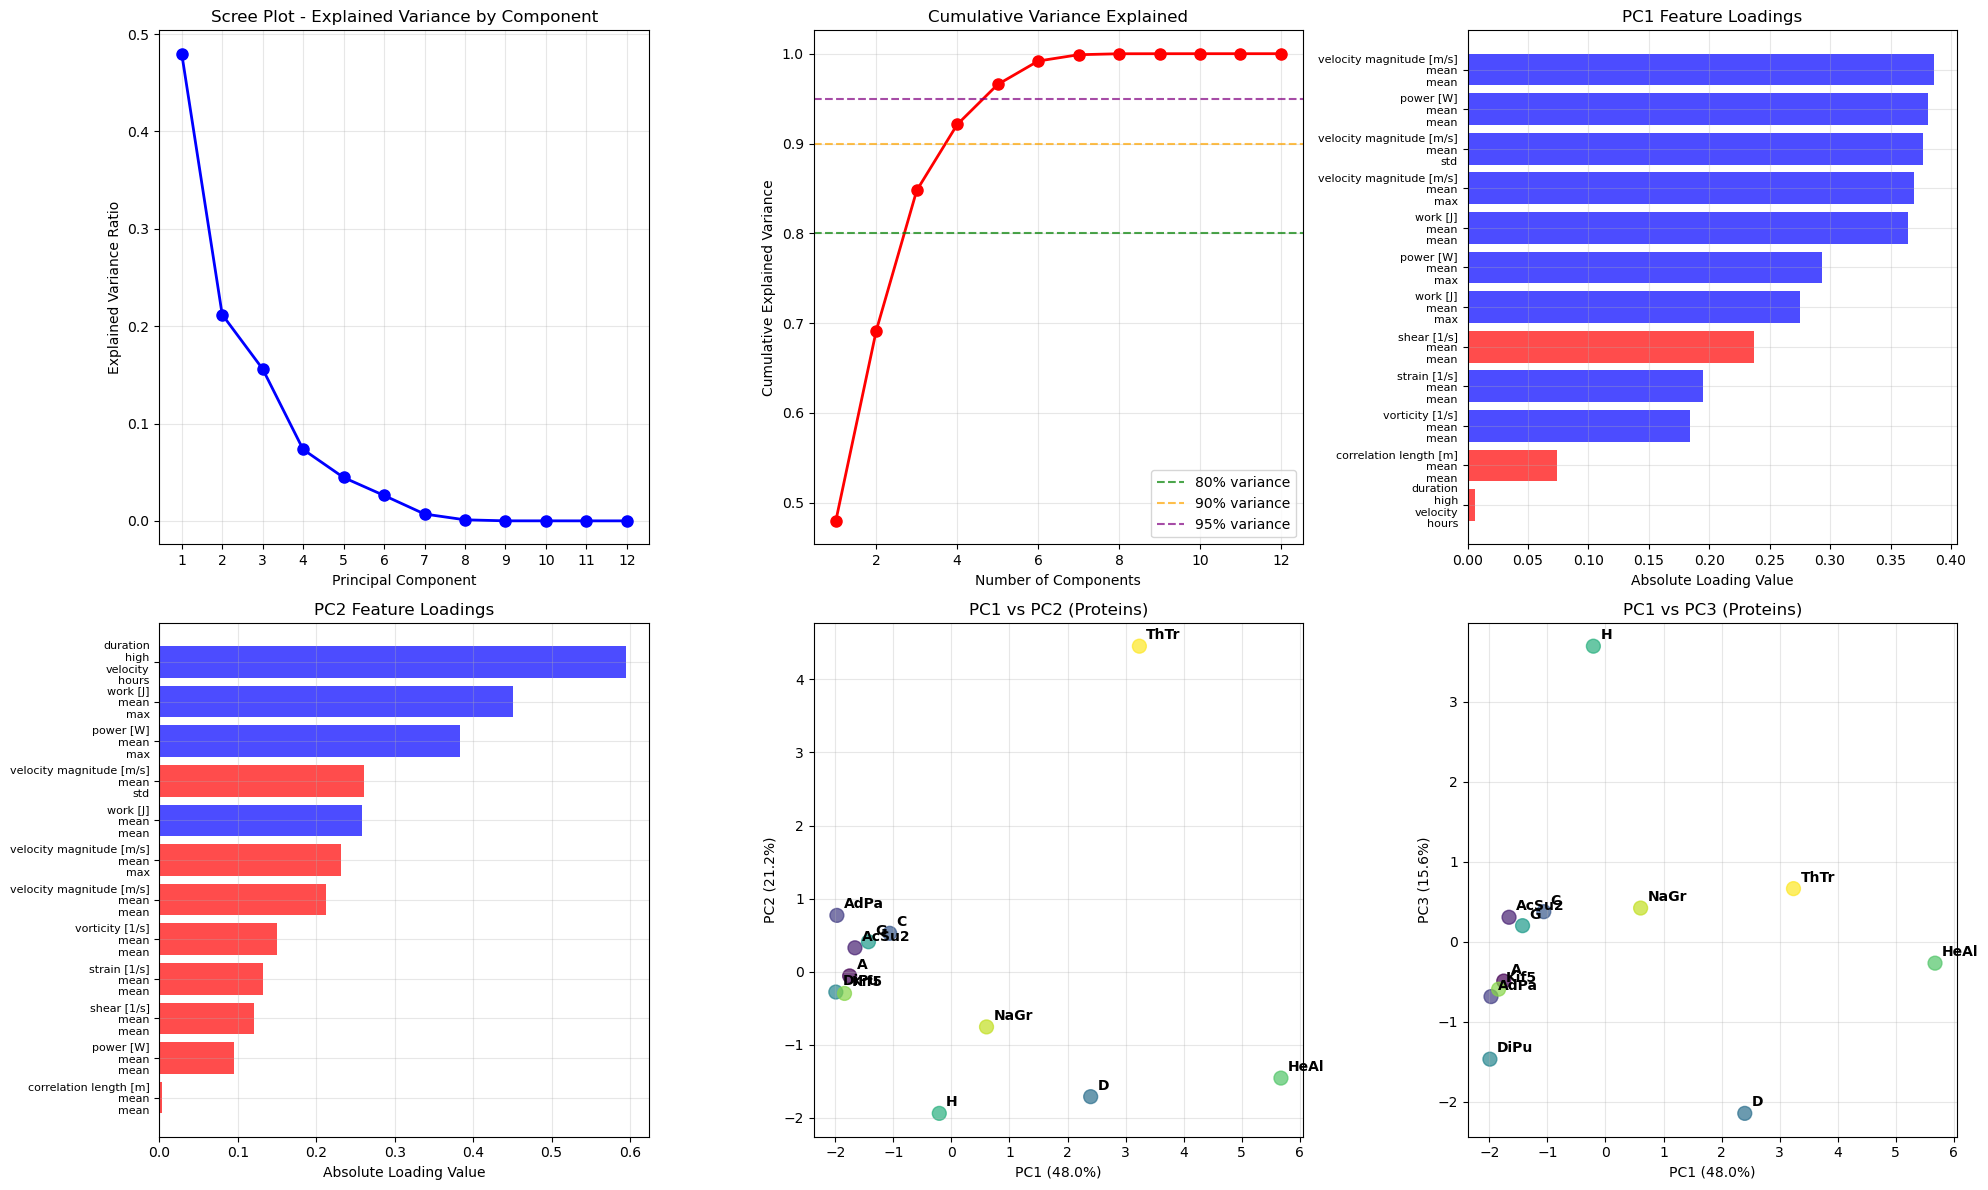


DETAILED VARIANCE EXPLANATION:
Total features used: 12
Total variance explained: 1.0000 (100.00%)
Components for 80% variance: 3
Components for 90% variance: 4
Components for 95% variance: 5

FEATURES USED IN PCA:
 1. velocity magnitude [m/s]_mean_mean
 2. velocity magnitude [m/s]_mean_max
 3. velocity magnitude [m/s]_mean_std
 4. power [W]_mean_mean
 5. power [W]_mean_max
 6. work [J]_mean_mean
 7. work [J]_mean_max
 8. vorticity [1/s]_mean_mean
 9. shear [1/s]_mean_mean
10. strain [1/s]_mean_mean
11. correlation length [m]_mean_mean
12. duration_high_velocity_hours

PC1 CONTRIBUTIONS (explains 48.0% of variance):
  velocity magnitude [m/s]_mean_mean      : 0.3860 (positive)
  power [W]_mean_mean                     : 0.3807 (positive)
  velocity magnitude [m/s]_mean_std       : 0.3771 (positive)
  velocity magnitude [m/s]_mean_max       : 0.3692 (positive)
  work [J]_mean_mean                      : 0.3642 (positive)
  power [W]_mean_max                      : 0.2930 (positive)
  wo

In [11]:
# Analyze which features contribute most to each principal component
print("Feature contributions to principal components:")
print("=" * 60)

# Get feature loadings (coefficients)
feature_loadings = pca.components_

# Create a DataFrame for easier analysis
loadings_df = pd.DataFrame(feature_loadings.T, 
                          columns=[f'PC{i+1}' for i in range(len(feature_loadings))],
                          index=available_features)

print("\nTop contributing features to PC1:")
pc1_contrib = loadings_df['PC1'].abs().sort_values(ascending=False)
for feature, loading in pc1_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

print("\nTop contributing features to PC2:")
pc2_contrib = loadings_df['PC2'].abs().sort_values(ascending=False)
for feature, loading in pc2_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

print("\nTop contributing features to PC3:")
pc3_contrib = loadings_df['PC3'].abs().sort_values(ascending=False)
for feature, loading in pc3_contrib.head(5).items():
    print(f"  {feature}: {loading:.4f}")

# Show the full loadings matrix
print("\nFull loadings matrix (first 5 components):")
print(loadings_df.iloc[:, :5].round(4))

# Create a comprehensive visualization of PCA results
print("\n" + "="*80)
print("PCA FEATURE ANALYSIS AND VARIANCE EXPLANATION")
print("="*80)

# Create a comprehensive PCA visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Scree plot
axes[0, 0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot - Explained Variance by Component')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, len(explained_variance_ratio) + 1))

# 2. Cumulative variance
axes[0, 1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2, markersize=8)
axes[0, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.7, label='80% variance')
axes[0, 1].axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% variance')
axes[0, 1].axhline(y=0.95, color='purple', linestyle='--', alpha=0.7, label='95% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Variance Explained')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Feature loadings for PC1
pc1_loadings = loadings_df['PC1'].abs().sort_values(ascending=True)
colors = ['red' if x < 0 else 'blue' for x in loadings_df['PC1'].loc[pc1_loadings.index]]
axes[0, 2].barh(range(len(pc1_loadings)), pc1_loadings.values, color=colors, alpha=0.7)
axes[0, 2].set_yticks(range(len(pc1_loadings)))
axes[0, 2].set_yticklabels([f.replace('_', '\n') for f in pc1_loadings.index], fontsize=8)
axes[0, 2].set_xlabel('Absolute Loading Value')
axes[0, 2].set_title('PC1 Feature Loadings')
axes[0, 2].grid(True, alpha=0.3)

# 4. Feature loadings for PC2
pc2_loadings = loadings_df['PC2'].abs().sort_values(ascending=True)
colors = ['red' if x < 0 else 'blue' for x in loadings_df['PC2'].loc[pc2_loadings.index]]
axes[1, 0].barh(range(len(pc2_loadings)), pc2_loadings.values, color=colors, alpha=0.7)
axes[1, 0].set_yticks(range(len(pc2_loadings)))
axes[1, 0].set_yticklabels([f.replace('_', '\n') for f in pc2_loadings.index], fontsize=8)
axes[1, 0].set_xlabel('Absolute Loading Value')
axes[1, 0].set_title('PC2 Feature Loadings')
axes[1, 0].grid(True, alpha=0.3)

# 5. PC1 vs PC2 scatter plot
scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=100, c=range(len(X_pca)), cmap='viridis')
axes[1, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC2 (Proteins)')
axes[1, 1].grid(True, alpha=0.3)

# Add protein names as labels
for i, protein in enumerate(df_protein_summary['protein']):
    axes[1, 1].annotate(protein, (X_pca[i, 0], X_pca[i, 1]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# 6. PC1 vs PC3 scatter plot
scatter = axes[1, 2].scatter(X_pca[:, 0], X_pca[:, 2], alpha=0.7, s=100, c=range(len(X_pca)), cmap='viridis')
axes[1, 2].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 2].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 2].set_title('PC1 vs PC3 (Proteins)')
axes[1, 2].grid(True, alpha=0.3)

# Add protein names as labels
for i, protein in enumerate(df_protein_summary['protein']):
    axes[1, 2].annotate(protein, (X_pca[i, 0], X_pca[i, 2]), 
                       xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed variance explanation
print(f"\nDETAILED VARIANCE EXPLANATION:")
print("=" * 50)
print(f"Total features used: {len(available_features)}")
print(f"Total variance explained: {cumulative_variance[-1]:.4f} ({cumulative_variance[-1]*100:.2f}%)")
print(f"Components for 80% variance: {np.where(cumulative_variance >= 0.8)[0][0] + 1}")
print(f"Components for 90% variance: {np.where(cumulative_variance >= 0.9)[0][0] + 1}")
print(f"Components for 95% variance: {np.where(cumulative_variance >= 0.95)[0][0] + 1}")

print(f"\nFEATURES USED IN PCA:")
print("=" * 30)
for i, feature in enumerate(available_features, 1):
    print(f"{i:2d}. {feature}")

print(f"\nPC1 CONTRIBUTIONS (explains {explained_variance_ratio[0]*100:.1f}% of variance):")
print("=" * 60)
for feature, loading in pc1_contrib.items():
    direction = "positive" if loadings_df.loc[feature, 'PC1'] > 0 else "negative"
    print(f"  {feature:40s}: {loading:.4f} ({direction})")

print(f"\nPC2 CONTRIBUTIONS (explains {explained_variance_ratio[1]*100:.1f}% of variance):")
print("=" * 60)
for feature, loading in pc2_contrib.items():
    direction = "positive" if loadings_df.loc[feature, 'PC2'] > 0 else "negative"
    print(f"  {feature:40s}: {loading:.4f} ({direction})")


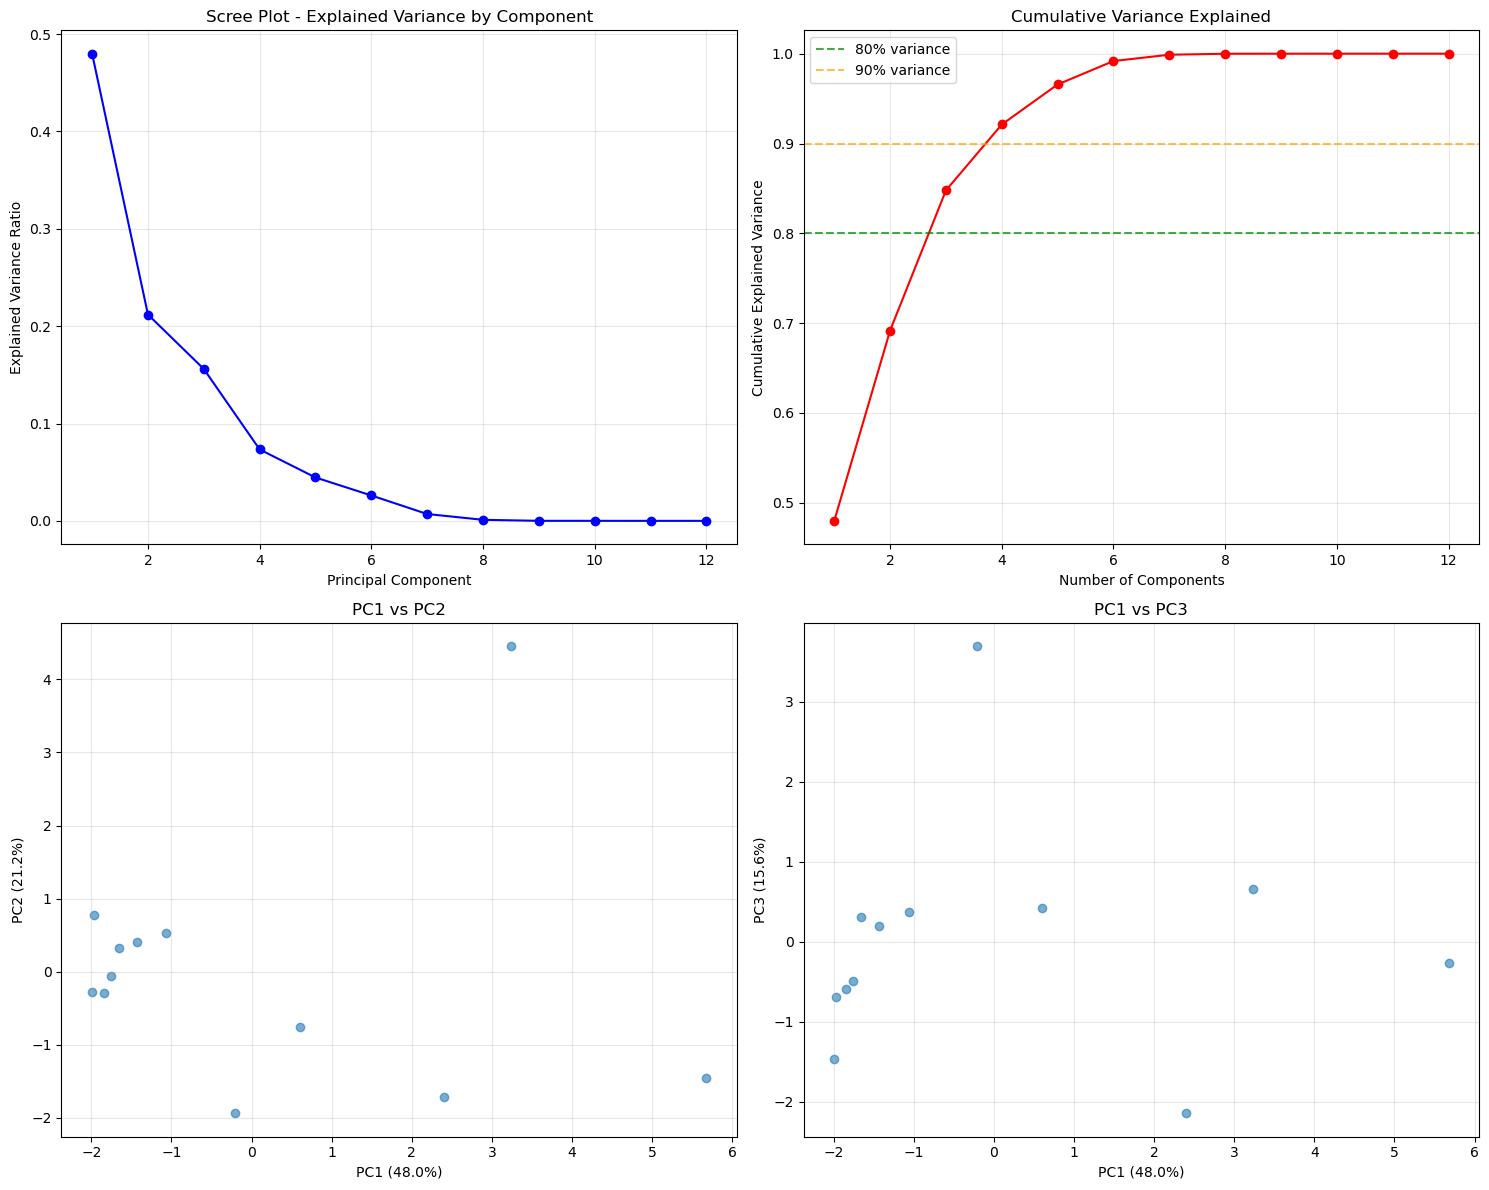

In [12]:
# Visualize PCA results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Scree plot
axes[0, 0].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-')
axes[0, 0].set_xlabel('Principal Component')
axes[0, 0].set_ylabel('Explained Variance Ratio')
axes[0, 0].set_title('Scree Plot - Explained Variance by Component')
axes[0, 0].grid(True, alpha=0.3)

# 2. Cumulative variance
axes[0, 1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
axes[0, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.7, label='80% variance')
axes[0, 1].axhline(y=0.9, color='orange', linestyle='--', alpha=0.7, label='90% variance')
axes[0, 1].set_xlabel('Number of Components')
axes[0, 1].set_ylabel('Cumulative Explained Variance')
axes[0, 1].set_title('Cumulative Variance Explained')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. PC1 vs PC2 scatter plot
axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
axes[1, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[1, 0].set_title('PC1 vs PC2')
axes[1, 0].grid(True, alpha=0.3)

# 4. PC1 vs PC3 scatter plot
axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 2], alpha=0.6)
axes[1, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 1].set_title('PC1 vs PC3')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


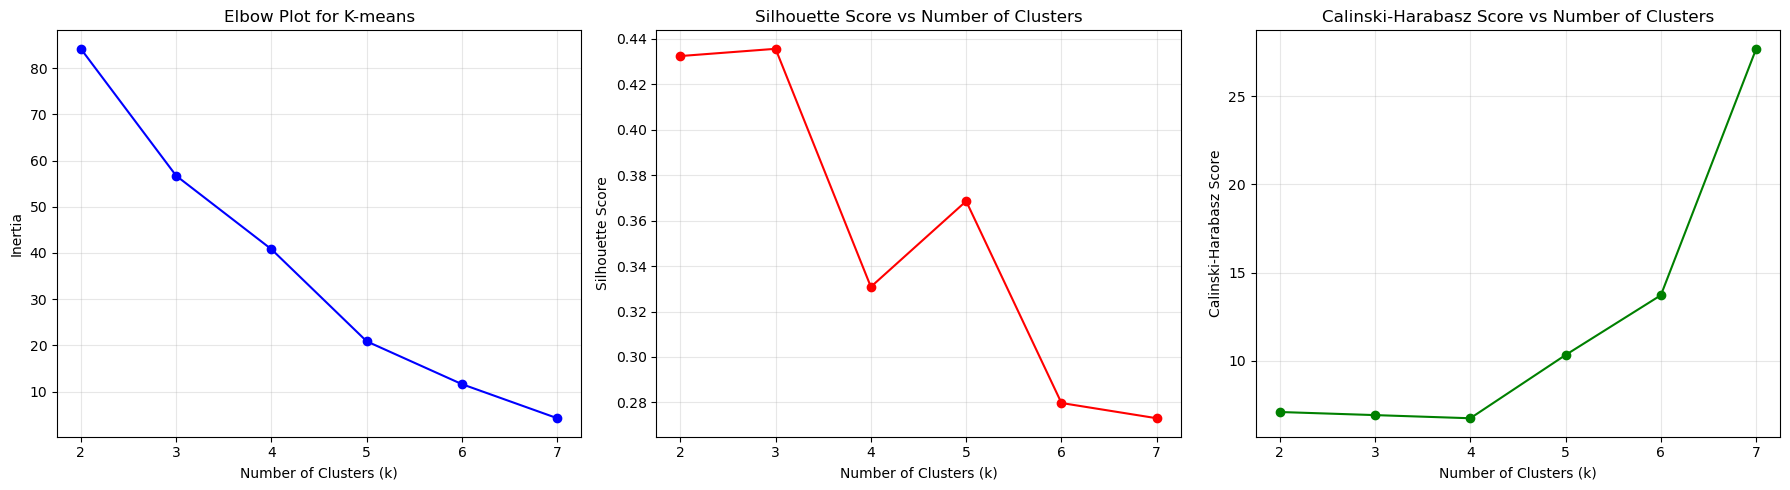

Optimal number of clusters based on silhouette score: 3
Silhouette score for k=3: 0.4356
Calinski-Harabasz score for k=3: 6.9219


In [13]:
# K-means clustering analysis
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score

# Test different numbers of clusters
k_range = range(2, 8)
inertias = []
silhouette_scores = []
calinski_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, cluster_labels))

# Plot clustering metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow plot
axes[0].plot(k_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot for K-means')
axes[0].grid(True, alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs Number of Clusters')
axes[1].grid(True, alpha=0.3)

# Calinski-Harabasz score
axes[2].plot(k_range, calinski_scores, 'go-')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('Calinski-Harabasz Score')
axes[2].set_title('Calinski-Harabasz Score vs Number of Clusters')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find optimal k
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")
print(f"Silhouette score for k={optimal_k}: {max(silhouette_scores):.4f}")
print(f"Calinski-Harabasz score for k={optimal_k}: {calinski_scores[optimal_k-2]:.4f}")


In [14]:
# Perform final K-means clustering with optimal k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Add cluster labels to the protein summary dataframe
df_protein_summary['kmeans_cluster'] = cluster_labels

# Analyze cluster characteristics
print("K-means Clustering Results:")
print("=" * 50)
print(f"Number of clusters: {optimal_k}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print()

# Analyze each cluster
for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"Cluster {cluster_id} ({len(cluster_data)} proteins):")
    
    # Get proteins in this cluster
    proteins = cluster_data['protein'].tolist()
    print(f"  Proteins: {', '.join(proteins)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  Concentrations tested: {cluster_data['DNA nM_nunique'].mean():.1f} ± {cluster_data['DNA nM_nunique'].std():.1f}")
    print()


K-means Clustering Results:
Number of clusters: 3
Silhouette score: 0.4356

Cluster 0 (9 proteins):
  Proteins: A, AcSu2, AdPa, C, DiPu, G, H, Kif5, NaGr
  Duration: 26.2 ± 13.8 hours
  Avg velocity: 23.6 ± 27.5 nm/s
  Max velocity: 291.1 ± 449.4 nm/s
  Min velocity: 0.0 ± 0.0 nm/s
  Concentrations tested: 7.2 ± 2.3

Cluster 1 (2 proteins):
  Proteins: D, HeAl
  Duration: 3.0 ± 0.7 hours
  Avg velocity: 245.6 ± 72.4 nm/s
  Max velocity: 1658.8 ± 748.3 nm/s
  Min velocity: 0.0 ± 0.0 nm/s
  Concentrations tested: 8.0 ± 0.0

Cluster 2 (1 proteins):
  Proteins: ThTr
  Duration: 43.3 ± nan hours
  Avg velocity: 81.9 ± nan nm/s
  Max velocity: 586.4 ± nan nm/s
  Min velocity: 0.0 ± nan nm/s
  Concentrations tested: 10.0 ± nan



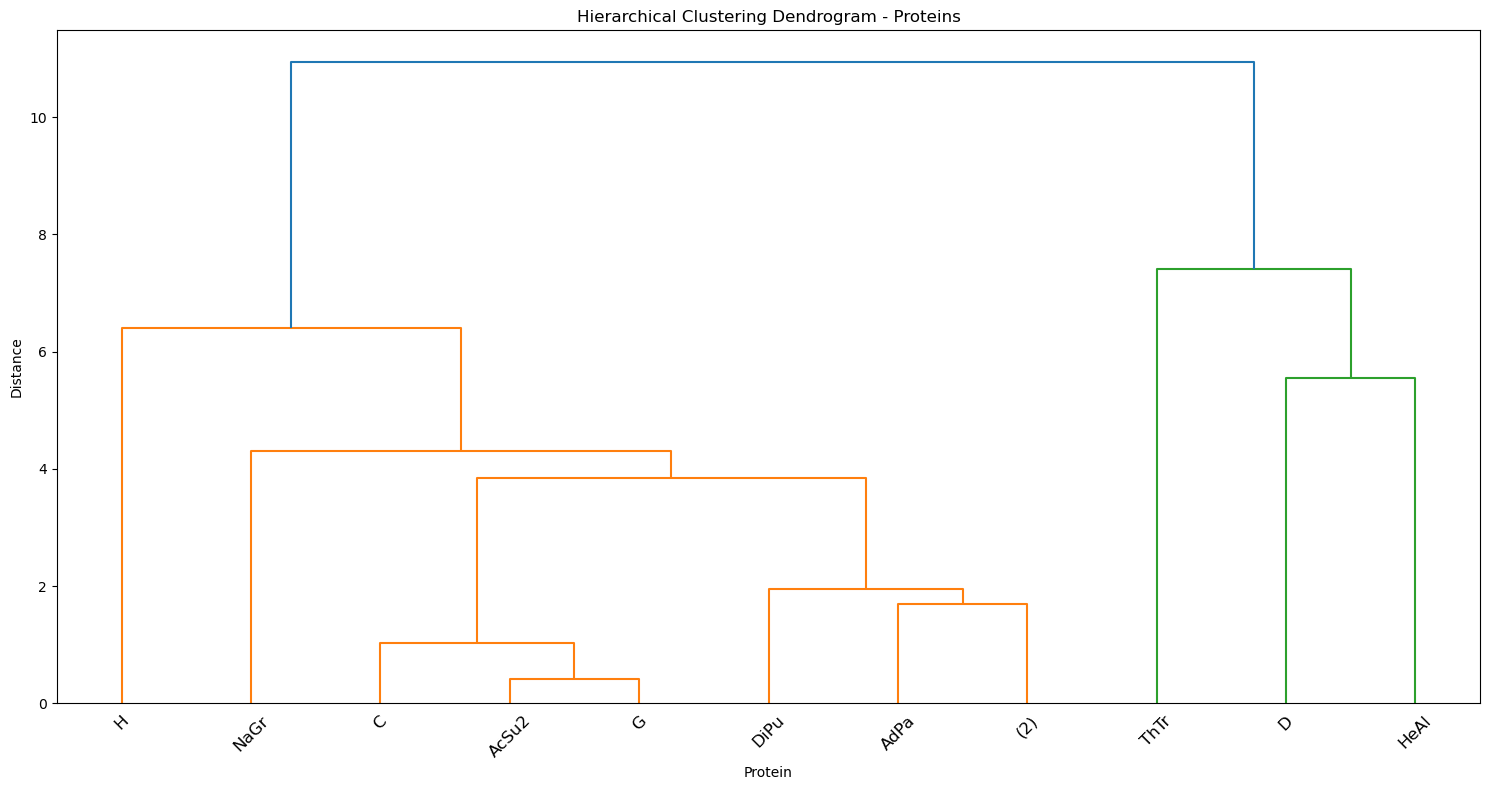

Clustering Comparison:
K-means silhouette score: 0.4356
Hierarchical silhouette score: 0.4356
Agreement between methods: 1.0000 (100.0%)

Protein cluster assignments:
A         : K-means=0, Hierarchical=0
AcSu2     : K-means=0, Hierarchical=0
AdPa      : K-means=0, Hierarchical=0
C         : K-means=0, Hierarchical=0
D         : K-means=1, Hierarchical=1
DiPu      : K-means=0, Hierarchical=0
G         : K-means=0, Hierarchical=0
H         : K-means=0, Hierarchical=0
HeAl      : K-means=1, Hierarchical=1
Kif5      : K-means=0, Hierarchical=0
NaGr      : K-means=0, Hierarchical=0
ThTr      : K-means=2, Hierarchical=2


In [15]:
# Hierarchical clustering analysis
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

# Perform hierarchical clustering
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

# Add hierarchical cluster labels
df_protein_summary['hierarchical_cluster'] = hierarchical_labels

# Create linkage matrix for dendrogram
linkage_matrix = linkage(X_scaled, method='ward')

# Plot dendrogram with protein names
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, 
           labels=df_protein_summary['protein'].values,
           truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram - Proteins')
plt.xlabel('Protein')
plt.ylabel('Distance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Compare K-means and Hierarchical clustering
print("Clustering Comparison:")
print("=" * 50)
print(f"K-means silhouette score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"Hierarchical silhouette score: {silhouette_score(X_scaled, hierarchical_labels):.4f}")

# Check agreement between methods
agreement = (cluster_labels == hierarchical_labels).sum() / len(cluster_labels)
print(f"Agreement between methods: {agreement:.4f} ({agreement*100:.1f}%)")

# Show which proteins are in which clusters
print("\nProtein cluster assignments:")
print("=" * 40)
for protein in df_protein_summary['protein']:
    kmeans_cluster = df_protein_summary[df_protein_summary['protein'] == protein]['kmeans_cluster'].iloc[0]
    hier_cluster = df_protein_summary[df_protein_summary['protein'] == protein]['hierarchical_cluster'].iloc[0]
    print(f"{protein:10s}: K-means={kmeans_cluster}, Hierarchical={hier_cluster}")


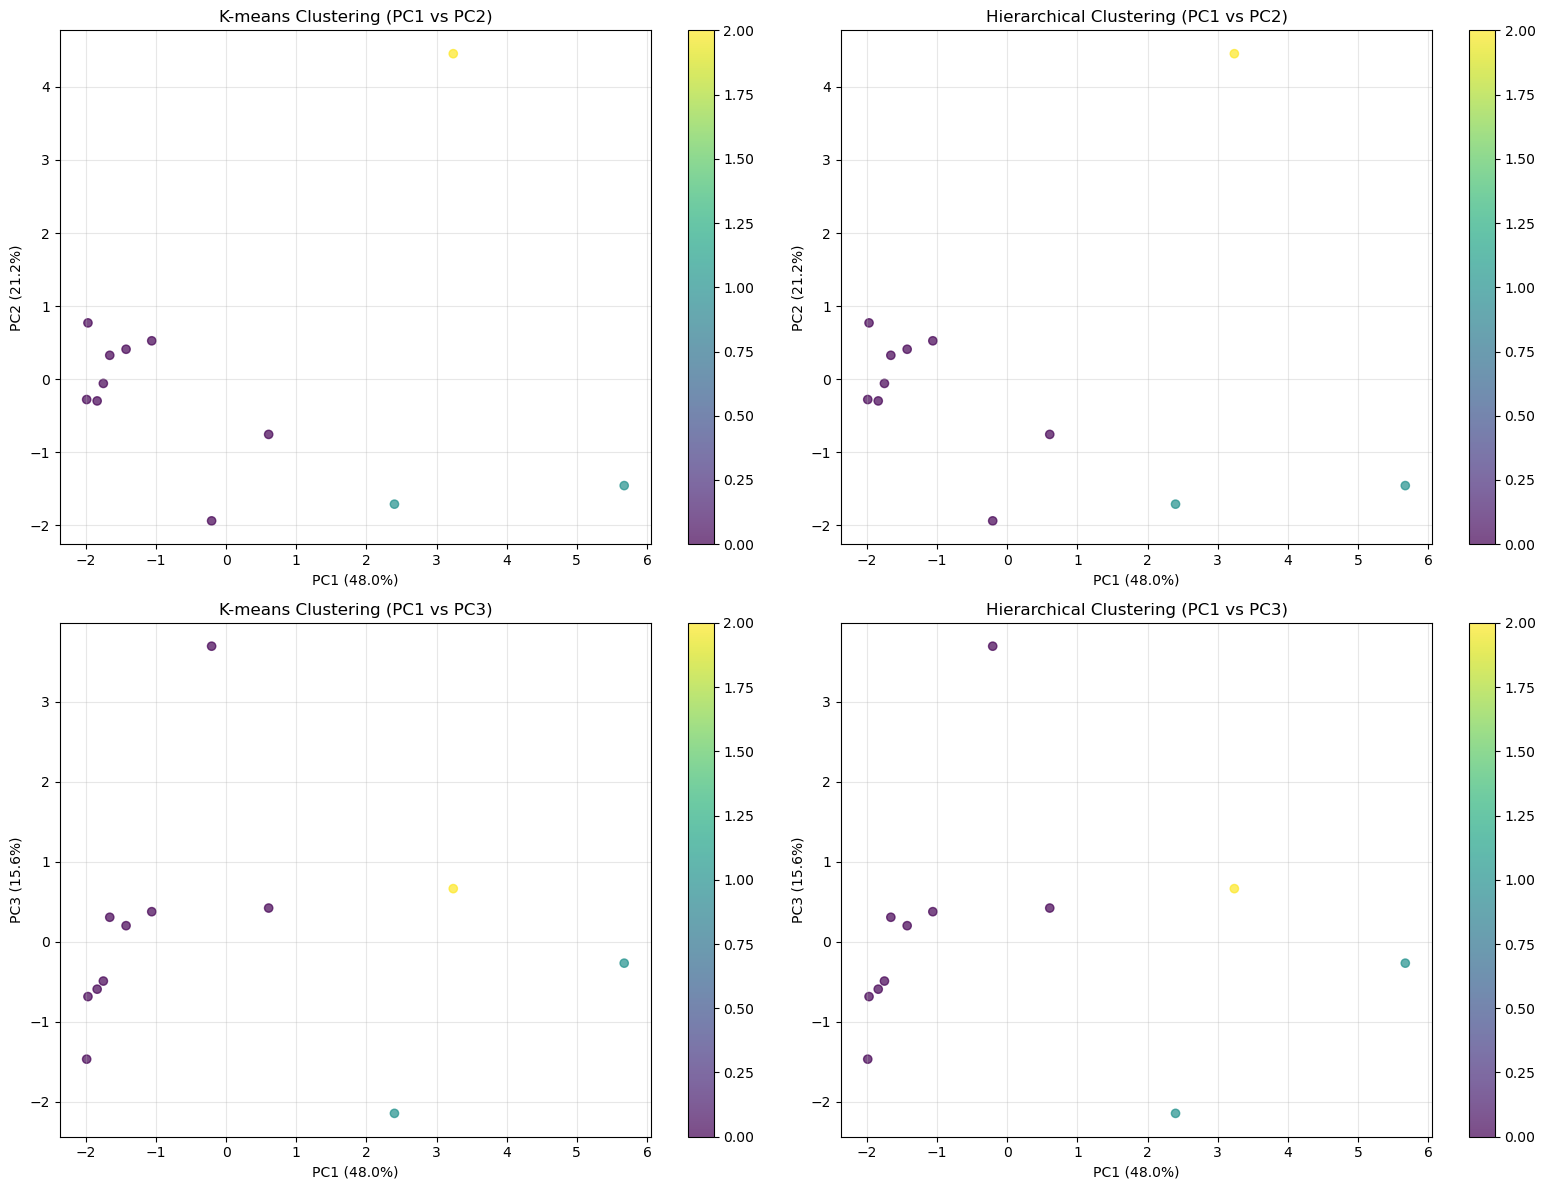

In [16]:
# Visualize clustering results in PCA space
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# K-means clustering in PCA space
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
axes[0, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[0, 0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[0, 0].set_title('K-means Clustering (PC1 vs PC2)')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0])

# Hierarchical clustering in PCA space
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=hierarchical_labels, cmap='viridis', alpha=0.7)
axes[0, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[0, 1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[0, 1].set_title('Hierarchical Clustering (PC1 vs PC2)')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1])

# K-means clustering in PC1 vs PC3 space
scatter3 = axes[1, 0].scatter(X_pca[:, 0], X_pca[:, 2], c=cluster_labels, cmap='viridis', alpha=0.7)
axes[1, 0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 0].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 0].set_title('K-means Clustering (PC1 vs PC3)')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0])

# Hierarchical clustering in PC1 vs PC3 space
scatter4 = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 2], c=hierarchical_labels, cmap='viridis', alpha=0.7)
axes[1, 1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1, 1].set_ylabel(f'PC3 ({explained_variance_ratio[2]*100:.1f}%)')
axes[1, 1].set_title('Hierarchical Clustering (PC1 vs PC3)')
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1])

plt.tight_layout()
plt.show()


In [17]:
# Let the natural groups emerge from clustering analysis
# No artificial behavioral classification - let the data speak for itself

print("NATURAL GROUP EMERGENCE FROM CLUSTERING")
print("=" * 60)
print("Letting the data determine the natural groupings without artificial constraints")
print()

# Analyze the natural clusters that emerged
print("Natural Cluster Analysis:")
print("=" * 40)

for cluster_id in range(optimal_k):
    cluster_data = df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id]
    print(f"\nNatural Cluster {cluster_id} ({len(cluster_data)} proteins):")
    
    # Get proteins in this cluster
    proteins = cluster_data['protein'].tolist()
    print(f"  Proteins: {', '.join(proteins)}")
    
    # Key metrics for this cluster
    duration_hours = cluster_data['time (s)_max'] / 3600
    avg_velocity = cluster_data['velocity magnitude [m/s]_mean_mean'] * 1e9  # Convert to nm/s
    max_velocity = cluster_data['velocity magnitude [m/s]_mean_max'] * 1e9   # Convert to nm/s
    min_velocity = cluster_data['velocity magnitude [m/s]_mean_min'] * 1e9   # Convert to nm/s
    velocity_std = cluster_data['velocity magnitude [m/s]_mean_std'] * 1e9    # Convert to nm/s
    
    print(f"  Duration: {duration_hours.mean():.1f} ± {duration_hours.std():.1f} hours")
    print(f"  Avg velocity: {avg_velocity.mean():.1f} ± {avg_velocity.std():.1f} nm/s")
    print(f"  Max velocity: {max_velocity.mean():.1f} ± {max_velocity.std():.1f} nm/s")
    print(f"  Min velocity: {min_velocity.mean():.1f} ± {min_velocity.std():.1f} nm/s")
    print(f"  Velocity variability: {velocity_std.mean():.1f} ± {velocity_std.std():.1f} nm/s")
    print(f"  Concentrations tested: {cluster_data['DNA nM_nunique'].mean():.1f} ± {cluster_data['DNA nM_nunique'].std():.1f}")
    
    # Characterize the cluster behavior
    if duration_hours.mean() > 12:
        duration_type = "Long-duration"
    elif duration_hours.mean() < 2:
        duration_type = "Short-duration"
    else:
        duration_type = "Medium-duration"
    
    if avg_velocity.mean() > 100:
        velocity_type = "High-velocity"
    elif avg_velocity.mean() < 20:
        velocity_type = "Low-velocity"
    else:
        velocity_type = "Medium-velocity"
    
    print(f"  Cluster characterization: {duration_type}, {velocity_type}")
    print(f"  Velocity range: {min_velocity.mean():.1f} - {max_velocity.mean():.1f} nm/s")


NATURAL GROUP EMERGENCE FROM CLUSTERING
Letting the data determine the natural groupings without artificial constraints

Natural Cluster Analysis:

Natural Cluster 0 (9 proteins):
  Proteins: A, AcSu2, AdPa, C, DiPu, G, H, Kif5, NaGr
  Duration: 26.2 ± 13.8 hours
  Avg velocity: 23.6 ± 27.5 nm/s
  Max velocity: 291.1 ± 449.4 nm/s
  Min velocity: 0.0 ± 0.0 nm/s
  Velocity variability: 36.0 ± 45.4 nm/s
  Concentrations tested: 7.2 ± 2.3
  Cluster characterization: Long-duration, Medium-velocity
  Velocity range: 0.0 - 291.1 nm/s

Natural Cluster 1 (2 proteins):
  Proteins: D, HeAl
  Duration: 3.0 ± 0.7 hours
  Avg velocity: 245.6 ± 72.4 nm/s
  Max velocity: 1658.8 ± 748.3 nm/s
  Min velocity: 0.0 ± 0.0 nm/s
  Velocity variability: 255.5 ± 70.2 nm/s
  Concentrations tested: 8.0 ± 0.0
  Cluster characterization: Medium-duration, High-velocity
  Velocity range: 0.0 - 1658.8 nm/s

Natural Cluster 2 (1 proteins):
  Proteins: ThTr
  Duration: 43.3 ± nan hours
  Avg velocity: 81.9 ± nan nm/s
  

ValueError: array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 2], dtype=int32) is not a valid value for color

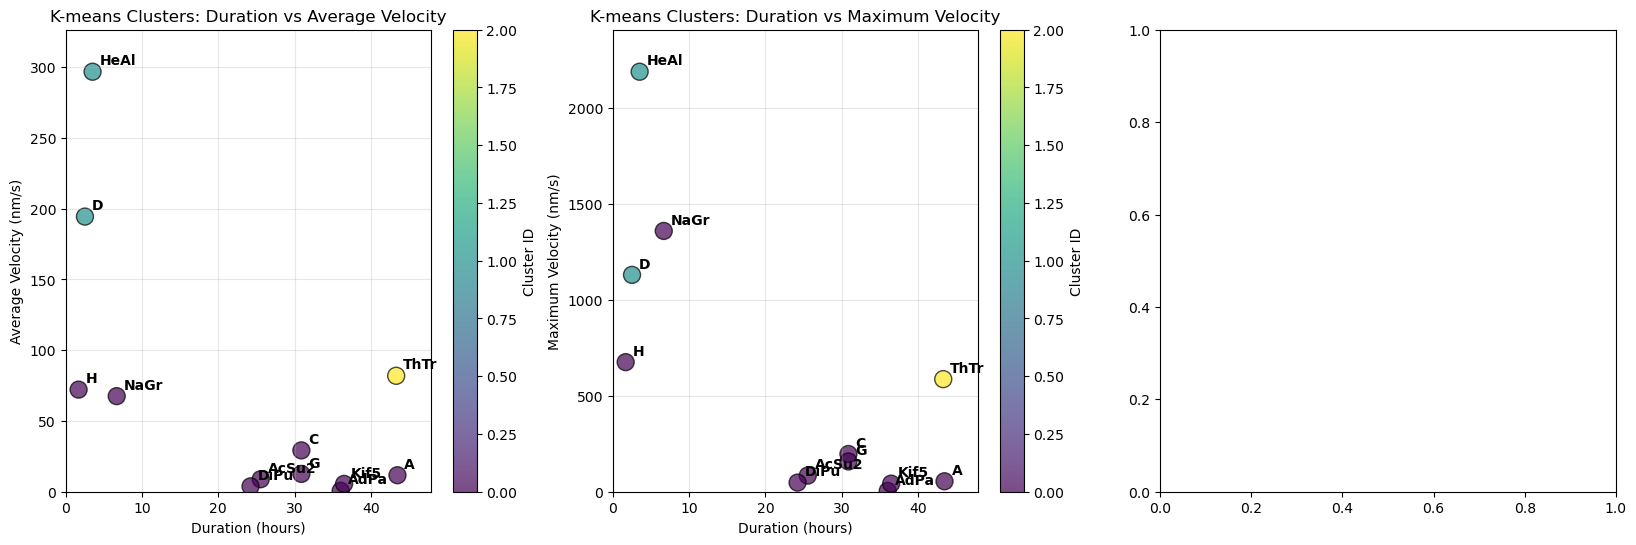

In [18]:
# Final visualization: Natural clusters in velocity-duration space
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Convert velocities to nm/s for better readability
duration_hours = df_protein_summary['time (s)_max'] / 3600
avg_velocity_nm_s = df_protein_summary['velocity magnitude [m/s]_mean_mean'] * 1e9
max_velocity_nm_s = df_protein_summary['velocity magnitude [m/s]_mean_max'] * 1e9
min_velocity_nm_s = df_protein_summary['velocity magnitude [m/s]_mean_min'] * 1e9

# Plot 1: K-means clusters with protein names
scatter1 = axes[0].scatter(duration_hours, avg_velocity_nm_s, c=cluster_labels, 
                          cmap='viridis', alpha=0.7, s=150, edgecolors='black', linewidth=1)
axes[0].set_xlabel('Duration (hours)')
axes[0].set_ylabel('Average Velocity (nm/s)')
axes[0].set_title('K-means Clusters: Duration vs Average Velocity')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, duration_hours.max() * 1.1)
axes[0].set_ylim(0, avg_velocity_nm_s.max() * 1.1)
plt.colorbar(scatter1, ax=axes[0], label='Cluster ID')

# Add protein names as labels
for i, (_, row) in enumerate(df_protein_summary.iterrows()):
    axes[0].annotate(row['protein'], 
                    (row['time (s)_max']/3600, row['velocity magnitude [m/s]_mean_mean']*1e9),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# Plot 2: Velocity range (min to max) vs duration
scatter2 = axes[1].scatter(duration_hours, max_velocity_nm_s, c=cluster_labels, 
                          cmap='viridis', alpha=0.7, s=150, edgecolors='black', linewidth=1)
axes[1].set_xlabel('Duration (hours)')
axes[1].set_ylabel('Maximum Velocity (nm/s)')
axes[1].set_title('K-means Clusters: Duration vs Maximum Velocity')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, duration_hours.max() * 1.1)
axes[1].set_ylim(0, max_velocity_nm_s.max() * 1.1)
plt.colorbar(scatter2, ax=axes[1], label='Cluster ID')

# Add protein names as labels
for i, (_, row) in enumerate(df_protein_summary.iterrows()):
    axes[1].annotate(row['protein'], 
                    (row['time (s)_max']/3600, row['velocity magnitude [m/s]_mean_max']*1e9),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

# Plot 3: Velocity range (min to max) vs duration with error bars
axes[2].errorbar(duration_hours, avg_velocity_nm_s, 
                yerr=[avg_velocity_nm_s - min_velocity_nm_s, max_velocity_nm_s - avg_velocity_nm_s],
                fmt='o', capsize=5, capthick=2, alpha=0.7, c=cluster_labels, cmap='viridis', s=100)
axes[2].set_xlabel('Duration (hours)')
axes[2].set_ylabel('Average Velocity (nm/s)')
axes[2].set_title('Velocity Range: Duration vs Average Velocity ± Range')
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(0, duration_hours.max() * 1.1)
axes[2].set_ylim(0, max_velocity_nm_s.max() * 1.1)

# Add protein names as labels
for i, (_, row) in enumerate(df_protein_summary.iterrows()):
    axes[2].annotate(row['protein'], 
                    (row['time (s)_max']/3600, row['velocity magnitude [m/s]_mean_mean']*1e9),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print("SUMMARY OF QUANTITATIVE ANALYSIS:")
print("=" * 60)
print(f"Total proteins analyzed: {len(df_protein_summary)}")
print(f"Proteins: {', '.join(df_protein_summary['protein'].tolist())}")
print(f"Optimal number of clusters: {optimal_k}")
print(f"PCA components explaining 80% variance: {np.where(cumulative_variance >= 0.8)[0][0] + 1}")
print(f"PCA components explaining 90% variance: {np.where(cumulative_variance >= 0.9)[0][0] + 1}")
print()
print("Top contributing features to PC1:")
for feature, loading in pc1_contrib.head(3).items():
    print(f"  {feature}: {loading:.4f}")
print()
print("Natural cluster distribution:")
for cluster_id in range(optimal_k):
    cluster_size = len(df_protein_summary[df_protein_summary['kmeans_cluster'] == cluster_id])
    print(f"  Cluster {cluster_id}: {cluster_size} proteins ({cluster_size/len(df_protein_summary)*100:.1f}%)")
